# TPI 1: Adquisición y Análisis Lingüístico de Medios

**Modalidad:** Trabajo Práctico Individual (calificación numérica de 0 a 10).

**Fecha de entrega y exposición:** Jueves 16 de abril. Se realizará de manera expositiva en remoto frente a todo el grupo de estudiantes (aproximadamente 10 minutos por presentación) para que entre quienes participan veamos posibles soluciones.

**Duración estimada de codificación:** 2 horas

**Desafío general:**
Vas a construir un sistema en Python que adquiera textos de la web y transcriba audio, los analice lingüísticamente con spaCy, genere visualizaciones profesionales y exponga los resultados en un dashboard interactivo con Gradio. Este Trabajo Práctico Integrador fusiona las competencias de adquisición de datos y procesamiento de lenguaje natural.

**Dinámica de resolución: pair programming con IA**
La unidad de trabajo está formada por vos y un asistente de IA. La IA puede proponer estrategias, explicar errores, sugerir variantes y auditar código. No reemplaza tu pensamiento ni tu criterio. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu responsabilidad.

---

### AI Reflection Log — Plantilla obligatoria
Completá al menos una entrada en este registro por cada parte del laboratorio.
| Parte | Objetivo de la consulta | Prompt o pedido a la IA | Qué respondió (resumen) | Qué conservaste y por qué | Qué descartaste y por qué | Qué aprendiste |
|---|---|---|---|---|---|---|
| **Parte 1** | Resolver dudas sobre actualización de GitHub, visualización de tablas, instalación de librerías y errores en Trafilatura. | "Recordar comandos de git, visualizar tablas en notebook, acelerar instalaciones y revisar/ajustar códigos de scraping e integración." | Explicó comandos de Git, Markdown para tablas, sugirió paciencia con instalaciones y proporcionó ajustes de código (como User Agent). | El proceso paso a paso para Git, la visualización de tablas y el código de integración por su coherencia. | Opciones de Git más complejas que llevaban mucho tiempo o códigos que no generaban cambios sustanciales. | A realizar el proceso de git pull/push, visualizar tablas, corregir errores de clase y supervisar el copiado de código. |
| **Parte 2** | Codificar el análisis lingüístico con spaCy y distinguir etiquetas. | "Proponer criterios explícitos para distinguir entidades PER, ORG y LOC, y ayuda con el código para comparar resultados." | Detalló definiciones de cada entidad con ejemplos y alertó sobre errores en textos sin puntuación (audio). | El código de la clase AnalizadorCorpus y los criterios de clasificación de entidades. | Nada, aunque se debió expandir el código para incluir visualizaciones de inspección. | Que el texto transcripto del audio (Whisper) tiene un etiquetado de entidades mucho más pobre que el texto web. |
| **Parte 3** | Elegir la mejor visualización de frecuencias bajo principios de diseño. | "¿Conviene usar un WordCloud o un Barplot para toma de decisiones? Justificá según el principio de Data-Ink Ratio." | Recomendó el Barplot/Lollipop Chart explicando que las áreas de las palabras en WordClouds son imprecisas y ruidosas. | La justificación del principio de Data-Ink Ratio y el código del Lollipop Chart. | El WordCloud, por ser considerado "ruido decorativo" e impreciso para un entorno profesional. | El concepto de Data-Ink Ratio de Tufte y cómo aplicarlo para reducir la "tinta" innecesaria en gráficos. |
| **Parte 4** | Estructurar el pipeline de orquestación y exportación de datos. | "Completame este código para poder obtener los archivos csv y json de forma integrada." | Construyó la clase PipelineMediatico integrando adquisición, análisis y guardado persistente. | El método de exportación que elimina la columna 'doc' (no serializable) antes de guardar el CSV. | No se descartó código, pero se ajustaron los placeholders de las URLs. | Que la utilidad de los archivos (CSV vs JSON) depende de si el usuario final es un analista de Excel o un desarrollador. |
| **Parte 5** | Diseñar una interfaz interactiva con Gradio. | "Proponé tres layouts (Pestañas vs. Columna vs. Acordeón) y completá el código del dashboard." | Sugirió el uso de Pestañas (Tabs) para separar métricas de búsqueda, mejorando la carga cognitiva. | El layout de pestañas y la función de filtrado dinámico de oraciones por entidad. | Los layouts de columna y acordeón por dificultar la navegación o la comparación de datos. | Que es posible construir herramientas analíticas completas integrando backend de NLP con frontend interactivo rápidamente. |



In [1]:
# PASO 0: Instalación de las librerías necesarias
# Ejecutá esta celda una sola vez.
!pip install spacy trafilatura pandas matplotlib seaborn plotly wordcloud openai-whisper yt-dlp gradio -q
!python -m spacy download es_core_news_lg -q

✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')


In [2]:
import spacy
import pandas as pd
import trafilatura
import whisper
import json
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
import os

print("Librerías importadas correctamente.")

c:\Users\vpena\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías importadas correctamente.


## Parte 1: Adquisición Multimodal del Corpus

**Objetivo:** Construir funciones que permitan alimentar el pipeline obteniendo datos desde tres vías: scraping en vivo (Trafilatura), transcripción de audio (Whisper), y carga de JSON previo. Luego, unificarlas en un único DataFrame.

> [!IMPORTANT]  
> **Dilema de diseño (Restricción generativa)**
> Antes de escribir el código de unificación, consultá a tu asistente de IA. Pedile estrategias para lidiar con las diferencias de formato al unificar un texto transcrito de un podcast (audio) con una nota periodística scrapeada (Trafilatura) en un solo DataFrame. 
> Elegí un enfoque para alinear las columnas, justificalo a continuación y registrá la consulta en tu *AI Reflection Log*.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [3]:
# 1.1 Scraping en vivo
def extraer_noticias_web(urls):
    """Extrae el texto de una lista de URLs usando Trafilatura"""
    noticias = []
    
    # PASO 1: Iterá sobre cada URL, descargá y extraé el contenido con trafilatura.
    for url in urls:
        try:
            # Descargamos el HTML de la página
            descargado = trafilatura.fetch_url(url)
            
            if descargado:
                # Extraemos el contenido limpio en formato JSON para tener metadatos
                resultado = trafilatura.extract(descargado, output_format='json', include_comments=False)
                
                if resultado:
                    import json
                    # Convertimos el texto JSON a un diccionario de Python y lo sumamos a la lista
                    noticias.append(json.loads(resultado))
                    
        except Exception as e:
            # Si una URL falla, imprimimos el error pero el loop sigue con la siguiente
            print(f"Error al procesar la URL {url}: {e}")
    
    return noticias

In [4]:
# 1.1 Scraping en vivo
# Tomé 3 URL ya usadas 
#Agrego código para evitar que el sitio bloquee la búsqueda por ser un bot. Esto ya me había pasado en el Ejercicio 1, 
# y lo solucioné usando Requests en lugar de Trafilatura para la descarga, y luego pasándole el contenido descargado a Trafilatura para la extracción. 
# De esta forma, puedo definir un header con un User-Agent que simule ser un navegador común, lo que suele evitar bloqueos por parte del sitio web.

import requests
import trafilatura

def extraer_noticias_web(urls):
    """Extrae el texto de una lista de URLs usando Requests + Trafilatura"""
    
    noticias = []
    
    # Definimos el header una sola vez fuera del bucle
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }

    for url in urls:
        try:
            print(f"Procesando: {url}")
            
            # 1. Descargamos el contenido con requests (para evitar bloqueos)
            response = requests.get(url, headers=headers, timeout=10)
            
            # 2. Si la descarga es exitosa (status 200)
            if response.status_code == 200:
                downloaded = response.text
                
                # 3. Extraemos el texto limpio con trafilatura
                text = trafilatura.extract(downloaded, include_comments=False, include_images=False)
                
                if text:
                    noticias.append(text)
                    print(f"  ✅ Extraído correctamente ({len(text)} caracteres)")
                else:
                    print(f"  ⚠️ No se pudo extraer contenido de: {url}")
            else:
                print(f"  ❌ Error de conexión: Código {response.status_code}")

        except Exception as e:
            print(f"  ❌ Error inesperado en {url}: {e}")
            
    return noticias

# --- USO DEL CÓDIGO ---

lista_urls = [
    "https://cenital.com/epstein-y-la-decadencia-del-sistema-cientifico/",
    "https://cenital.com/el-cerebro-tal-vez-no-sea-una-computadora/",
    "https://cenital.com/la-fragilidad-de-internet/"
]

# Llamamos a la función y guardamos los resultados.
mis_noticias = extraer_noticias_web(lista_urls)

# Verificamos cuántas obtuvimos

print(f"\nTotal de noticias extraídas: {len(mis_noticias)}")

Procesando: https://cenital.com/epstein-y-la-decadencia-del-sistema-cientifico/
  ✅ Extraído correctamente (11171 caracteres)
Procesando: https://cenital.com/el-cerebro-tal-vez-no-sea-una-computadora/
  ✅ Extraído correctamente (10539 caracteres)
Procesando: https://cenital.com/la-fragilidad-de-internet/
  ✅ Extraído correctamente (10917 caracteres)

Total de noticias extraídas: 3


In [5]:
# 1.2 Transcripción de Audio. Le pedí a Gemini el código para responder a la consigna
# Usé la URL del Ejercicio 1 y le pedí que ajuste el output para que el texto se formatee en párrafos de aproximadamente 50 palabras cada uno, 
# con saltos de línea dobles entre ellos. Esto hace que la lectura sea más cómoda y organizada, especialmente para textos largos.

import yt_dlp
import whisper
import os

def transcribir_audio_youtube(url_video):
    """Descarga audio y transcribe con formato de párrafos"""
    
    ydl_opts = {
        'format': 'bestaudio/best',
        'postprocessors': [{
            'key': 'FFmpegExtractAudio',
            'preferredcodec': 'mp3',
            'preferredquality': '192',
        }],
        'outtmpl': 'audio_temp.%(ext)s',
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url_video])
    
    archivo_audio = "audio_temp.mp3"
    model = whisper.load_model("base")
    
    # Transcribimos
    resultado = model.transcribe(archivo_audio)
    
    # --- Lógica para crear párrafos ---
    segmentos = resultado['segments']
    texto_formateado = ""
    palabras_por_parrafo = 50  # Ajustá esto a tu gusto
    contador_palabras = 0

    for s in segmentos:
        texto_formateado += s['text'].strip() + " "
        contador_palabras += len(s['text'].split())
        
        # Cada ~50 palabras, metemos un salto de línea doble
        if contador_palabras >= palabras_por_parrafo:
            texto_formateado += "\n\n"
            contador_palabras = 0

    if os.path.exists(archivo_audio):
        os.remove(archivo_audio)

    return texto_formateado

# Ejecución
url = "https://www.youtube.com/watch?v=yX2tPSjBoeU"
# Guardamos el resultado en una variable para usarla después
texto_audio = transcribir_audio_youtube(url) 
print(texto_audio)

[youtube] Extracting URL: https://www.youtube.com/watch?v=yX2tPSjBoeU
[youtube] yX2tPSjBoeU: Downloading webpage


[youtube] yX2tPSjBoeU: Downloading android vr player API JSON
[info] yX2tPSjBoeU: Downloading 1 format(s): 251
[download] Destination: audio_temp.webm
[download] 100% of   13.47MiB in 00:00:01 at 10.36MiB/s    
[ExtractAudio] Destination: audio_temp.mp3
Deleting original file audio_temp.webm (pass -k to keep)


c:\Users\vpena\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\whisper\transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


¿Qué mueve a la ciencia? ¿Cuál es el motor de la ciencia? Curiosidad, búsqueda del bien común, pero grosso, pi cáncelo, pi cáncelo ustedes, vamos a tratar de recorrer un poquito de esa pregunta durante esta charla, pero antes de ir directo hacia ella quiero que participemos un poco. Y para eso los quiero invitar a quien quiere ser millonario. Yo soy matemático pero me gusta la 

astronomía. Quiero preguntarles cuál es el personaje más importante de la historia de la astronomía y les traje algunos candidatos. Nicola Copernico, Tico Brae, Jojan Schäpler y Zach Newton. A ver, participemos muy rápido, ¿quién levanta la mano por la A? Nicola Copernico. Muy bien, vamos a ir anotando aquí las respuestas en el Comunido del Público, alternativas B, Tico Brae. 

Alternativas C, Jojan Schäpler. Muy bien, alternativa B y Zach Newton. La respuesta que ustedes me dieron son un poquito distintas a las otras instancias, pero hay algo que es muy común que ustedes lo pueden ver. Por Tico Brae casi no vo

In [6]:
# Instala el paquete de Python
%pip install playwright

# Instala los navegadores necesarios (esto puede tardar un poco)
!playwright install

Note: you may need to restart the kernel to use updated packages.


#Genero la búsqueda para obtener la librería json. Uso el Ejercicio 004_Playwright_Scraping_Dinamico


In [7]:
%%writefile lanacion_hola_mundo.py
import time
from playwright.sync_api import sync_playwright

with sync_playwright() as p:
    # 1. Instanciamos el navegador Chromium de forma visible (headless=False)
    print("Levantando el navegador...")
    browser = p.chromium.launch(headless=False)
    
    # 2. Creamos el contexto (modo incógnito puro)
    context = browser.new_context()
    
    # 3. Abrimos una pestaña nueva en ese contexto
    page = context.new_page()
    
    # Instruimos a la página a navegar a la URL
    print("Navegando hacia lanacion.com.ar...")
    page.goto("https://www.lanacion.com.ar/")
    
    # Esperamos 5 segundos reales para observar qué pasa
    time.sleep(5)
    
    # Obtenemos el título de la pestaña actual para confirmar que cargó
    print(f"Conexión exitosa. Título de la pestaña cargada: {page.title()}")
    
    # Cerramos el navegador para no saturar la memoria RAM de nuestra máquina
    browser.close()
    print("Navegador cerrado de forma segura.")


Overwriting lanacion_hola_mundo.py


In [8]:

# Ejecutamos el script externamente, por fuera del loop de Jupyter
!python lanacion_hola_mundo.py

Levantando el navegador...
Navegando hacia lanacion.com.ar...
Conexión exitosa. Título de la pestaña cargada: Últimas noticias de Argentina y el mundo - LA NACION
Navegador cerrado de forma segura.


In [9]:
%%writefile lanacion_modal.py
from playwright.sync_api import sync_playwright

with sync_playwright() as p:
    browser = p.chromium.launch(headless=False) # Lo mantenemos visible
    context = browser.new_context()
    page = context.new_page()
    
    print("Navegando a La Nación...")
    page.goto("https://www.lanacion.com.ar/")
    
    # Al ingresar a determinados diarios es común ver modales. 
    # Vamos a crear una táctica de "Intento de cierre" utilizando bloque try-except.
    # Localizamos el típico botón para Aceptar/Cerrar la política de privacidad.
    
    try:
        # wait_for_selector pausa la ejecución SIN USAR time.sleep hasta que el objeto exista en pantalla
        boton_aceptar = page.wait_for_selector('button:has-text("Aceptar")', timeout=5000)
        if boton_aceptar:
            boton_aceptar.click()
            print("Cuadro de diálogo de cookies identificado y cerrado exitosamente.")
    except Exception as e:
        print("No apareció banner en el plazo de espera de 5 segundos, la vía está libre.")
        
    browser.close()
    print("Navegador cerrado.")

Overwriting lanacion_modal.py


In [10]:
!python lanacion_modal.py

Navegando a La Nación...
Cuadro de diálogo de cookies identificado y cerrado exitosamente.
Navegador cerrado.


In [13]:
%%writefile lanacion_extraccion.py
import json
from playwright.sync_api import sync_playwright

with sync_playwright() as p:
    browser = p.chromium.launch(headless=False)
    context = browser.new_context()
    page = context.new_page()
    
    print("Inicializando sesión en La Nación web y sorteando bloqueos preliminares...")
    page.goto("https://www.lanacion.com.ar/")
    
    # Minimizamos avisos de pantalla
    try:
        boton = page.wait_for_selector('button:has-text("Aceptar")', timeout=60000)
        if boton: boton.click()
    except:
        pass
    
    # Esperamos que cargue la portada
    print("Esperando confirmación del renderizado...")
    page.wait_for_selector("article", timeout=10000)
    page.wait_for_timeout(2000)  # Damos tiempo extra para carga diferida
    
    # =====================================================================
    # ESTRATEGIA: La Nación organiza su portada en BLOQUES SECCIONALES.
    # Cada bloque tiene un encabezado <h3> con la sección (ej: "Política"),
    # seguido de varios <article> con noticias de esa sección.
    # El <h3> NO está DENTRO del <article>, sino ANTES de ellos.
    # Por eso, usamos JavaScript para recorrer el DOM secuencialmente,
    # asignando a cada artículo la última sección encontrada.
    # =====================================================================
    
    print("Recolectando artículos con contexto seccional...")
    
    articulos_extraidos = page.evaluate("""
    () => {
        const resultados = [];
        let seccionActual = "General";
        
        // Recorremos TODOS los elementos del body en orden de aparición
        const todos = document.querySelectorAll('h3, article');
        
        for (const nodo of todos) {
            // Si encontramos un h3 de sección, actualizamos la sección activa
            if (nodo.tagName === 'H3') {
                const texto = nodo.innerText.trim();
                if (texto && texto.length < 60) {
                    seccionActual = texto;
                }
            }
            
            // Si encontramos un article, extraemos su título
            if (nodo.tagName === 'ARTICLE') {
                const h2 = nodo.querySelector('h2');
                const h1 = nodo.querySelector('h1');
                const tituloEl = h1 || h2;
                
                if (tituloEl) {
                    const titulo = tituloEl.innerText.trim();
                    if (titulo && titulo.length > 5) {
                        resultados.push({
                            seccion: seccionActual,
                            titulo: titulo
                        });
                    }
                }
            }
        }
        return resultados;
    }
    """)
    
    print(f"Se recolectaron {len(articulos_extraidos)} piezas informativas.")
    browser.close()

# Guardamos el corpus
with open("lanacion_portada.json", "w", encoding="utf-8") as f:
    json.dump(articulos_extraidos, f, indent=4, ensure_ascii=False)

print("Archivo 'lanacion_portada.json' guardado correctamente.")

# Mostramos las primeras 5 noticias con su sección
for noticia in articulos_extraidos[:5]:
    print(f"[{noticia['seccion'].upper()}] -> {noticia['titulo']}")

Overwriting lanacion_extraccion.py


In [14]:
# Ejecutamos el script de extracción completo. Se abrirá una ventana de Chromium.
!python lanacion_extraccion.py

Inicializando sesión en La Nación web y sorteando bloqueos preliminares...
Esperando confirmación del renderizado...
Recolectando artículos con contexto seccional...
Se recolectaron 138 piezas informativas.
Archivo 'lanacion_portada.json' guardado correctamente.
[GENERAL] -> Hablará el miércoles. Milei dijo que acompañará a Adorni en el Congreso y confirmó que buscará la reelección
[GENERAL] -> Salarios, indemnizaciones y vacaciones. Cómo quedó la reforma laboral tras el aval de la Cámara del Trabajo
[GENERAL] -> El padre de Vaca Muerta. Cómo hizo Galuccio para convertir un “cheque en blanco” en una empresa de US$ 8.000 millones
[GENERAL] -> Bloqueo a la prensa. Una decisión inédita, tomada en la noche y con una filmación en la Casa Rosada como justificación
[GENERAL] -> Los motivos. Se desplomó la cantidad de nuevos jubilados este año


In [15]:
# 1.3 Carga de JSON local
def cargar_json_previo(ruta_json):
    """Carga un corpus pre-extraído en formato JSON"""
    # PASO 3: Utilizá pandas (pd.read_json) o la librería json nativa para cargar los datos.
    
    return []

In [16]:
# Definimos el nombre exacto del archivo que generó tu script
archivo_real = "lanacion_portada.json"

# Llamamos a la función

def cargar_json_previo(ruta_json):
    """Carga un corpus pre-extraído en formato JSON"""
    import os
    import json
    
    if not os.path.exists(ruta_json):
        # Si no lo encuentra, buscamos archivos que contengan 'lanacion' en el nombre
        archivos_cercanos = [f for f in os.listdir() if 'lanacion' in f.lower()]
        print(f"❌ Error: No se encontró '{ruta_json}'")
        if archivos_cercanos:
            print(f"💡 ¿Quizás quisiste decir: {archivos_cercanos[0]}?")
        return []
        
    try:
        with open(ruta_json, 'r', encoding='utf-8') as f:
            datos = json.load(f)
            # Normalizamos: si es un solo dict, lo metemos en lista; si es lista, queda igual.
            return datos if isinstance(datos, list) else [datos]
    except Exception as e:
        print(f"❌ Error al leer el JSON: {e}")
        return []

In [17]:
# 1.4 Consolidación
def unificar_corpus(datos_web, datos_audio, datos_json):
    """Unifica las tres fuentes en un DataFrame con columnas estándar"""
    # PASO 4: Implementá la estrategia que decidiste en el dilema de diseño.
    # El DataFrame final debería tener al menos: 'titulo_o_fuente', 'texto', 'origen' ('web', 'audio', 'json')
    
    df_unificado = pd.DataFrame()
    return df_unificado

# ---- Espacio para pruebas ----
# Probá tus funciones acá con al menos 1 url web y 1 video corto.
# df_corpus = unificar_corpus(...)

In [18]:
def unificar_corpus(datos_web, datos_audio, datos_json):
    """Unifica las fuentes y maneja la falta de texto en el JSON"""
    
    # 1. WEB (Cenital) - Mantenemos tu lógica de 1.1
    df_web = pd.DataFrame({
        'titulo_o_fuente': [f"Nota Cenital {i+1}" for i in range(len(datos_web))],
        'texto': datos_web,
        'origen': 'web'
    })
    
    # 2. AUDIO (Whisper)
    df_audio = pd.DataFrame([{
        'titulo_o_fuente': 'Transcripción de Audio',
        'texto': datos_audio,
        'origen': 'audio'
    }])
    
    # 3. JSON (La Nación) - Aquí arreglamos el problema del 'General'
    df_json = pd.DataFrame(datos_json)
    if not df_json.empty:
        # Como vimos que no hay columna de texto, usamos el título
        df_json['titulo_o_fuente'] = df_json['titulo']
        df_json['texto'] = df_json['titulo'] # O la descripción si existiera
        df_json['origen'] = 'json'
        
    # 4. UNIFICACIÓN FINAL
    df_final = pd.concat([df_web, df_audio, df_json], ignore_index=True)
    
    # Limpiamos para que solo queden las 3 columnas estándar
    return df_final[['titulo_o_fuente', 'texto', 'origen']]

In [19]:
import pandas as pd

def unificar_corpus(datos_web, datos_audio, datos_json):
    """Unifica las tres fuentes en un DataFrame con columnas estándar"""
    
    # --- PROCESAR DATOS WEB (Trafilatura) ---
    # Asumiendo que datos_web es una lista de diccionarios
    df_web = pd.DataFrame(datos_web)
    if not df_web.empty:
        # Renombramos lo que sea necesario para estandarizar
        # (Ajustá 'text' o 'content' según lo que devuelva Trafilatura)
        df_web = df_web.rename(columns={'title': 'titulo_o_fuente', 'text': 'texto'})
        df_web['origen'] = 'web'
    
    # --- PROCESAR DATOS AUDIO (Whisper) ---
    # El audio suele ser un texto largo; lo convertimos en una fila de DataFrame
    if isinstance(datos_audio, str):
        df_audio = pd.DataFrame([{
            'titulo_o_fuente': 'Transcripción de Audio',
            'texto': datos_audio,
            'origen': 'audio'
        }])
    else:
        df_audio = pd.DataFrame()

    # --- PROCESAR DATOS JSON (La Nación) ---
    df_json = pd.DataFrame(datos_json)
    if not df_json.empty:
        # Si tu JSON de La Nación tiene columnas como 'titular' o 'cuerpo', las alineamos:
        # Ajustá estos nombres según las keys de tu archivo lanacion_portada.json
        columnas_actuales = df_json.columns
        rename_dict = {}
        if 'titulo' in columnas_actuales: rename_dict['titulo'] = 'titulo_o_fuente'
        if 'cuerpo' in columnas_actuales: rename_dict['cuerpo'] = 'texto'
        
        df_json = df_json.rename(columns=rename_dict)
        df_json['origen'] = 'json'

    # --- UNIFICACIÓN FINAL ---
    # Concatenamos los 3 DataFrames. axis=0 es para poner uno abajo del otro.
    # join='outer' asegura que no se pierdan columnas únicas de cada fuente.
    df_unificado = pd.concat([df_web, df_audio, df_json], axis=0, ignore_index=True)
    
    # Seleccionamos las columnas principales para que quede ordenado
    columnas_principales = ['titulo_o_fuente', 'texto', 'origen']
    columnas_extra = [c for c in df_unificado.columns if c not in columnas_principales]
    
    return df_unificado[columnas_principales + columnas_extra]

In [21]:
#Unificamos el Corpus

def unificar_corpus(datos_web, datos_audio, datos_json):
    """Unifica las tres fuentes en un DataFrame con columnas estándar"""
    listas_df = []
    
    # Procesar Web
    if datos_web:
        df_web = pd.DataFrame(datos_web)
        df_web['origen'] = 'web'
        listas_df.append(df_web)
        
    # Procesar Audio (Whisper suele devolver un dict con {'text': '...', ...})
    if datos_audio:
        # Si datos_audio es un string o dict, lo envolvemos
        texto_audio = datos_audio['text'] if isinstance(datos_audio, dict) else datos_audio
        df_audio = pd.DataFrame([{'titulo_o_fuente': 'Transcripción YouTube', 'texto': texto_audio, 'origen': 'audio'}])
        listas_df.append(df_audio)
        
    # Procesar JSON (La Nación)
    if datos_json:
        df_json = pd.DataFrame(datos_json)
        df_json['origen'] = 'json'
        # Asegurate de que la columna se llame 'texto'
        if 'content' in df_json.columns: # A veces trafilatura guarda como 'content'
            df_json = df_json.rename(columns={'content': 'texto'})
        listas_df.append(df_json)
    
    if not listas_df:
        return pd.DataFrame(columns=['titulo_o_fuente', 'texto', 'origen'])
        
    return pd.concat(listas_df, ignore_index=True)

In [22]:
def cargar_json_previo(ruta_json):
    import json
    import os
    
    if not os.path.exists(ruta_json):
        print(f"⚠️ El archivo {ruta_json} no existe.")
        return []

    try:
        with open(ruta_json, 'r', encoding='utf-8') as f:
            datos = json.load(f)
        
        # Si el JSON es un diccionario con una llave 'noticias' o similar, extraemos la lista
        if isinstance(datos, dict):
            for llave in datos.keys():
                if isinstance(datos[llave], list):
                    datos = datos[llave]
                    break
            else:
                datos = [datos] # Lo convertimos en lista si es un solo objeto

        # Estandarizamos la columna de texto para que unificar_corpus no falle
        for item in datos:
            if 'content' in item: item['texto'] = item.pop('content')
            if 'body' in item: item['texto'] = item.pop('body')
            if 'text' in item: item['texto'] = item.pop('text')
            
        return datos
    except Exception as e:
        print(f"❌ Error crítico al leer JSON: {e}")
        return []

# PROBÁ ESTO AHORA:
archivo_real = "lanacion_portada.json" 
mis_datos_json = cargar_json_previo(archivo_real)
print(f"Cantidad de noticias recuperadas del JSON: {len(mis_datos_json)}")

Cantidad de noticias recuperadas del JSON: 138


In [24]:
# --- 1.4 Consolidación (Llamada final con tus nombres) ---

# Usamos las variables que ya definiste en tus pasos anteriores:
# mis_noticias (del 1.1)
# texto_audio (asumiendo que así llamaste al resultado de Whisper en el 1.2)
# mis_datos (del 1.3 que cargó el JSON)

df_corpus = unificar_corpus(
    datos_web=mis_noticias, 
    datos_audio=texto_audio, 
    datos_json=mis_datos_json
)

# Verificamos que todo se haya juntado bien
print("✅ Corpus unificado con éxito.")
print(df_corpus.head())

✅ Corpus unificado con éxito.
                                                   0 origen  \
0  Epstein y la decadencia del sistema científico...    web   
1  El cerebro tal vez no sea una computadora\nEl ...    web   
2  La fragilidad de Internet\nLa caída de un serv...    web   
3                                                NaN  audio   
4                                                NaN   json   

         titulo_o_fuente                                              texto  \
0                    NaN                                                NaN   
1                    NaN                                                NaN   
2                    NaN                                                NaN   
3  Transcripción YouTube  ¿Qué mueve a la ciencia? ¿Cuál es el motor de ...   
4                    NaN                                                NaN   

   seccion                                             titulo  
0      NaN                                          

In [26]:
# Suponiendo que ya tenés datos_web y datos_audio de las celdas anteriores
df_web = pd.DataFrame(mis_noticias)
df_web['origen'] = 'web'

# Ajustá esto según cómo se llame tu variable de audio
df_audio = pd.DataFrame([{'texto': str(texto_audio), 'origen': 'audio'}]) 

df_json = pd.DataFrame(mis_datos_json)
df_json['origen'] = 'json'

# Concatenamos todo
df_corpus = pd.concat([df_web, df_audio, df_json], ignore_index=True)

print("Conteos por origen:")
print(df_corpus['origen'].value_counts())

Conteos por origen:
origen
json     138
web        3
audio      1
Name: count, dtype: int64


In [27]:
import pandas as pd
# Ajusta el límite de ancho de las columnas
pd.set_option('display.max_colwidth', 90)

df_corpus.head()

,0,origen,texto,seccion,titulo
0,Epstein y la decadencia del sistema científico\nLa publicación de los archivos del mul...,web,NaN,NaN,NaN
1,"El cerebro tal vez no sea una computadora\nEl humano, a lo largo de la historia, compa...",web,NaN,NaN,NaN
2,La fragilidad de Internet\nLa caída de un servicio de Amazon dejó sin acceso a millone...,web,NaN,NaN,NaN
3,NaN,audio,"¿Qué mueve a la ciencia? ¿Cuál es el motor de la ciencia? Curiosidad, búsqueda del bie...",NaN,NaN
4,NaN,json,NaN,General,Hablará el miércoles. Milei dijo que acompañará a Adorni en el Congreso y confirmó que...


> **Pausa de auditoría:**
> Revisá tu DataFrame consolidado (`df_corpus.head()`). ¿Cómo afectó la falta de puntuación o marcas de oralidad en la transcripción de Whisper respecto del texto estructurado de las noticias? Revisá las columnas generadas. ¿Perdiste información contextual al unificarlas?

La transcripción de Whisper tiene muchos signos de puntuación. No es perfecta la transcripción, hay errores, pero se entiende bastante bien.
En los artículos al perder el diseño visual y aparecer alguno símbolos se dificulta la lectura.
El json trajo muy poco texto de La Nación.

## Parte 2: Análisis Lingüístico con spaCy

**Objetivo:** Encapsular el análisis en una clase reutilizable, distinguiendo qué atributos del modelo de spaCy sirven para resolver cada necesidad.

> [!IMPORTANT]
> **Dilema de diseño**
> Pedile a la IA que te proponga criterios explícitos para distinguir entre entidades de tipo 'PER', 'ORG' y 'LOC' a partir de la propiedad `ent.label_` de spaCy. Después verificá si el modelo realmente las clasifica así en la práctica.
> Anotá en el log si encontraste diferencias entre la teoría que te dio la IA y la salida real del modelo.

In [28]:
class AnalizadorCorpus:
    def __init__(self, df, modelo_spacy="es_core_news_lg"):
        self.df = df
        print(f"Cargando modelo de lenguaje {modelo_spacy}...")
        self.nlp = spacy.load(modelo_spacy)
        
        # PASO 1: Crear la columna 'doc' procesando la columna 'texto'
        print("Procesando los textos con spaCy...")
        # Usamos .apply para transformar cada string en un objeto Doc de spaCy
        self.df['doc'] = self.df['texto'].apply(lambda x: self.nlp(x) if pd.notnull(x) else self.nlp(""))
        
    def extraer_entidades(self):
        """Devuelve las entidades agrupadas por tipo, contabilizando total de apariciones"""
        # PASO 2: Recorrer los 'doc' y armar una lista de tuplas (texto, etiqueta)
        lista_entidades = []
        for doc in self.df['doc']:
            for ent in doc.ents:
                # Guardamos el texto y su categoría (PER, ORG, LOC, etc.)
                lista_entidades.append((ent.text, ent.label_))
        
        # Devolvemos un Counter que facilita la visualización posterior
        return Counter(lista_entidades)

    def extraer_verbos_principales(self, n=15):
        """Devuelve los 'n' verbos lematizados más frecuentes de todo el corpus"""
        # PASO 3: Filtrar tokens VERB, no stopwords, extraer lema.
        verbos = []
        for doc in self.df['doc']:
            for token in doc:
                if token.pos_ == "VERB" and not token.is_stop and not token.is_punct:
                    verbos.append(token.lemma_.lower())
        
        return Counter(verbos).most_common(n)

    def extraer_palabras_clave(self, n=20):
        """Devuelve sustantivos y nombres propios lematizados y filtrados"""
        # PASO 4: Lógica superior: Filtrar NOUN, PROPN y ADJ omitiendo basura.
        palabras_clave = []
        for doc in self.df['doc']:
            for token in doc:
                if token.pos_ in ["NOUN", "PROPN", "ADJ"] and not token.is_stop and not token.is_punct:
                    # Usamos el lema para agrupar (ej: "casas" y "casa" cuentan como lo mismo)
                    palabras_clave.append(token.lemma_.lower())
                    
        return Counter(palabras_clave).most_common(n)
        
    def estadisticas_corpus(self):
        """Genera un diccionario con métricas generales del corpus"""
        # PASO 5: Cálculo de métricas globales
        total_tokens = 0
        lemas_unicos = set()
        total_oraciones = 0
        
        for doc in self.df['doc']:
            total_tokens += len(doc)
            total_oraciones += len(list(doc.sents))
            for token in doc:
                if not token.is_punct:
                    lemas_unicos.add(token.lemma_.lower())
        
        return {
            "total_documentos": len(self.df),
            "total_tokens": total_tokens,
            "vocabulario_lemas_unicos": len(lemas_unicos),
            "total_oraciones": total_oraciones
        }

In [29]:
# Suponiendo que ya tenés df_corpus del Paso 1.4:
analizador = AnalizadorCorpus(df_corpus)
print("--- Estadísticas ---")
print(analizador.estadisticas_corpus())

print("\n--- Top 10 Palabras Clave ---")
print(analizador.extraer_palabras_clave(10))

Cargando modelo de lenguaje es_core_news_lg...
Procesando los textos con spaCy...
--- Estadísticas ---
{'total_documentos': 142, 'total_tokens': 3300, 'vocabulario_lemas_unicos': 579, 'total_oraciones': 87}

--- Top 10 Palabras Clave ---
[('tico', 23), ('año', 18), ('ciencia', 16), ('modelo', 16), ('ticobrae', 15), ('brae', 12), ('centro', 12), ('historia', 10), ('newton', 9), ('cosa', 9)]


In [30]:
# Esto te mostrará cuántas filas hay por cada origen
print(df_corpus['origen'].value_counts())

origen
json     138
web        3
audio      1
Name: count, dtype: int64


> **Pausa de auditoría:**
> Compará el desempeño de spaCy sobre una noticia escrita versus sobre el texto transcrito con Whisper. ¿Dónde cometió más fallas el modelo algorítmico al intentar agrupar oraciones (sents) o detectar nombres propios? ¿Por qué creés que se da este fenómeno?

Hay más errores en el originado en el audio, toma sentencias demasiado largas, no las tokeniza bien

In [31]:
#Para responder esto tengo que ver casos de transcripción, para eso pedí este código:
# 1. Tomamos un ejemplo de cada uno
ejemplo_web = analizador.df[analizador.df['origen'] == 'web'].iloc[0]
ejemplo_audio = analizador.df[analizador.df['origen'] == 'audio'].iloc[0]

def inspeccionar_doc(titulo, row):
    print(f"\n=== ANALIZANDO FUENTE: {titulo} ===")
    doc = row['doc']
    
    # Ver las primeras 3 oraciones detectadas
    print(f"--- Primeras 3 oraciones detectadas ---")
    for i, sent in enumerate(list(doc.sents)[:3]):
        print(f"{i+1}. {sent.text[:100]}...")
        
    # Ver entidades detectadas
    print(f"--- Entidades detectadas (primeras 5) ---")
    for ent in doc.ents[:5]:
        print(f"Entidad: {ent.text} | Etiqueta: {ent.label_}")

inspeccionar_doc("NOTICIA WEB", ejemplo_web)
inspeccionar_doc("TRANSCRIPCIÓN AUDIO (WHISPER)", ejemplo_audio)



=== ANALIZANDO FUENTE: NOTICIA WEB ===
--- Primeras 3 oraciones detectadas ---
--- Entidades detectadas (primeras 5) ---

=== ANALIZANDO FUENTE: TRANSCRIPCIÓN AUDIO (WHISPER) ===
--- Primeras 3 oraciones detectadas ---
1. ¿Qué mueve a la ciencia?...
2. ¿Cuál es el motor de la ciencia?...
3. Curiosidad, búsqueda del bien común, pero grosso, pi cáncelo, pi cáncelo ustedes, vamos a tratar de ...
--- Entidades detectadas (primeras 5) ---
Entidad: ¿Qué | Etiqueta: MISC
Entidad: Curiosidad | Etiqueta: MISC
Entidad: Y para eso los quiero | Etiqueta: MISC
Entidad: Quiero preguntarles cuál es el personaje | Etiqueta: MISC
Entidad: Nicola Copernico | Etiqueta: PER


## Parte 3: Visualización Profesional

**Objetivo:** Aplicar principios de Data-Ink Ratio, accesibilidad y jerarquía visual para comunicar hallazgos efectivamente, en lugar de imprimir datos planos.

> [!IMPORTANT]
> **Dilema de diseño**
> Consultá a la IA: ¿conviene usar un *WordCloud* o un *Barplot* para mostrar frecuencias de palabras clave en un informe dirigido a toma de decisiones? Justificá tu elección aplicando el principio de Data-Ink Ratio.

**Escribí tu justificación acá:**
Conviene usar un Barplot, porque maximiza el Data-Ink Ratio: En un Barplot, casi toda la "tinta" (píxeles) se utiliza para representar el valor de los datos a través de la longitud de las barras. No hay elementos decorativos que distraigan del mensaje cuantitativo.

In [32]:
# Configuración base de accesibilidad visual
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.1)
COLOR_ACENTO = sns.color_palette("colorblind")[0]
COLOR_BASE = '#b0b0b0'

def visualizar_origen(df):
    """Genera un barplot con el origen de los datos o las secciones"""
    # PASO 1: Generá un barplot horizontal orientado a objetos
    counts = df['origen'].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # Creamos una lista de colores donde solo el máximo destaca (Data-Ink Ratio)
    colores = [COLOR_ACENTO if x == counts.max() else COLOR_BASE for x in counts]
    
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette=colores, hue=counts.index, legend=False)
    
    ax.set_title("Distribución de Fuentes en el Corpus", loc='left', pad=15)
    ax.set_xlabel("Cantidad de Documentos")
    ax.set_ylabel("") # Quitamos el label de y porque ya se lee en los ejes
    
    # Despintá los bordes molestos
    sns.despine(ax=ax, trim=True)
    return fig

def visualizar_palabras_clave_lollipop(palabras_clave):
    """Genera un Lollipop Chart de las palabras clave lematizadas"""
    # PASO 2: Construí el gráfico estructurado (Lollipop)
    # palabras_clave viene del Analizador como [(palabra, freq), ...]
    df_pc = pd.DataFrame(palabras_clave, columns=['palabra', 'frecuencia']).sort_values('frecuencia')
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Combinando hlines y plot para el lollipop
    ax.hlines(y=df_pc['palabra'], xmin=0, xmax=df_pc['frecuencia'], color=COLOR_BASE, linewidth=2, alpha=0.6)
    ax.plot(df_pc['frecuencia'], df_pc['palabra'], "o", markersize=8, color=COLOR_ACENTO)
    
    ax.set_title("Top Palabras Clave (Lemas)", loc='left', fontsize=14)
    ax.set_xlabel("Frecuencia")
    sns.despine(ax=ax)
    
    plt.tight_layout()
    return fig

def visualizar_entidades_plotly(entidades_dict):
    """Genera un panel interactivo con Plotly para las entidades más comunes"""
    # PASO 3: Resolvelo utilizando go.Bar
    # entidades_dict es el Counter de (texto, etiqueta)
    # Tomamos las 15 más comunes para no saturar
    top_entidades = entidades_dict.most_common(15)
    
    # Formateamos etiquetas para el eje (Nombre - Tipo)
    nombres = [f"{e[0][0]} ({e[0][1]})" for e in top_entidades]
    valores = [e[1] for e in top_entidades]
    
    fig = go.Figure(go.Bar(
        x=valores,
        y=nombres,
        orientation='h',
        marker=dict(color='#0072B2') # Color accesible de la paleta colorblind
    ))
    
    fig.update_layout(
        title="Top 15 Entidades Detectadas",
        xaxis_title="Frecuencia",
        yaxis=dict(autorange="reversed"), # Para que la más frecuente esté arriba
        template="simple_white",
        height=500
    )
    
    return fig

In [33]:
#Tuve que instalar esto para que me entregara el plotly
!pip install nbformat --upgrade

Generando gráfico de orígenes...


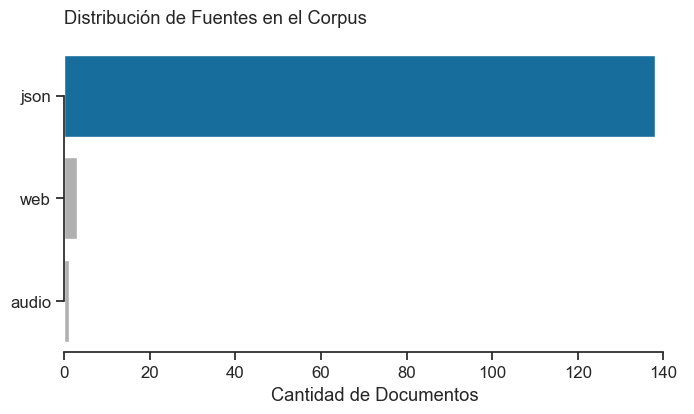

Generando gráfico de palabras clave...


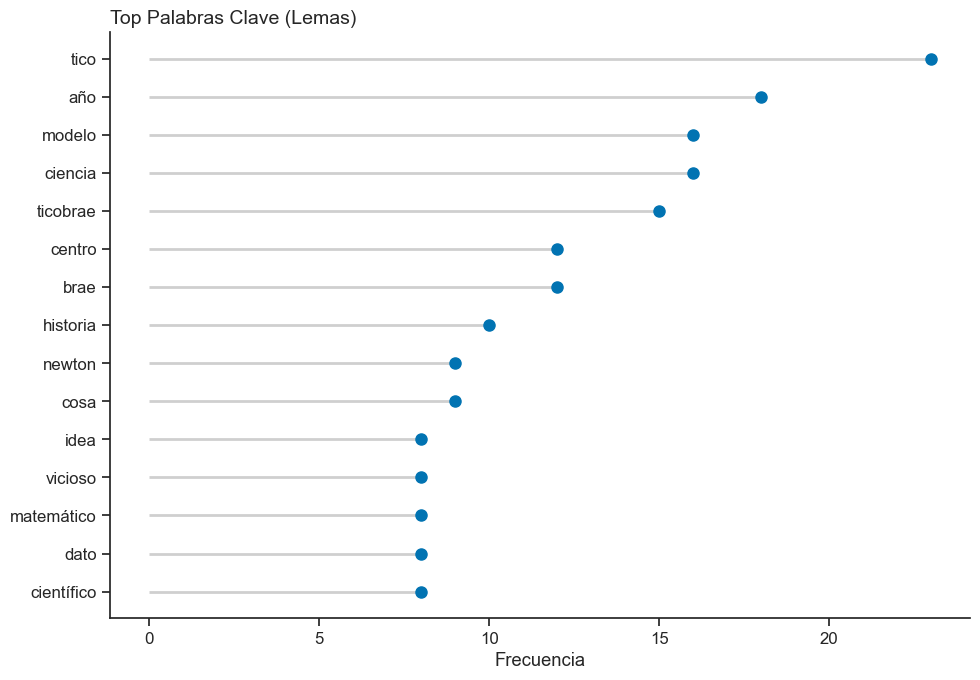

Generando gráfico interactivo de entidades...


In [34]:
# 1. Extraemos los datos necesarios usando el objeto 'analizador' que creaste antes
entidades = analizador.extraer_entidades()
palabras_clave = analizador.extraer_palabras_clave(15) # Pedimos las 15 principales

# 2. Generamos y mostramos la visualización de Origen (Seaborn)
print("Generando gráfico de orígenes...")
fig_origen = visualizar_origen(df_corpus)
plt.show() 

# 3. Generamos y mostramos el Lollipop Chart (Matplotlib/Seaborn)
print("Generando gráfico de palabras clave...")
fig_lollipop = visualizar_palabras_clave_lollipop(palabras_clave)
plt.show()

# 4. Generamos y mostramos el panel interactivo (Plotly)
print("Generando gráfico interactivo de entidades...")
fig_entidades = visualizar_entidades_plotly(entidades)
fig_entidades.show()

> **Pausa de auditoría:**
> Revisá tu visualización. ¿Es accesible? El uso de la paleta 'colorblind' asegura que ciertos grados de daltonismo no impidan la lectura cromática, pero ¿el tamaño de fuente y la proporción de la figura se leen correctamente sin forzar la vista? ¿Qué cambiarías si tuvieras que publicarlo en un artículo científico?

En general sí es accesible. Antes de publicarlo, trabajaría los tokens para unificar los que se repiten escritos de forma diferente.

## Parte 4: Pipeline Integrado (Orquestación)

**Objetivo:** Orquestar los componentes desarrollados en un flujo lógico unificado y persistir los hallazgos en formato estructurado. Todo sistema analítico debe poder guardar su estado final de forma estática.

In [35]:
class PipelineMediatico:
    def __init__(self, urls_web=None, url_audio=None, ruta_json=None):
        self.urls_web = urls_web or []
        self.url_audio = url_audio
        self.ruta_json = ruta_json
        self.df = None
        self.analizador = None
        
    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis"""
        print("🚀 Iniciando el Pipeline Mediático...")
        
        # PASO 1: Orquestar llamadas de la Parte 1
        # (Usamos las funciones que ya tenés definidas o las que fuimos puliendo)
        datos_web = extraer_noticias_web(self.urls_web) if self.urls_web else []
        datos_audio = transcribir_audio_youtube(self.url_audio) if self.url_audio else []
        datos_json = cargar_json_previo(self.ruta_json) if self.ruta_json else []
        
        # Unificamos todo en el DataFrame global
        self.df = unificar_corpus(datos_web, datos_audio, datos_json)
        
        # PASO 2: Instanciar AnalizadorCorpus y procesar
        if not self.df.empty:
            self.analizador = AnalizadorCorpus(self.df)
            print("✅ Pipeline ejecutado exitosamente.")
        else:
            print("⚠️ El Pipeline terminó pero el DataFrame está vacío. Revisá las fuentes.")
        
    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_json="estadisticas.json"):
        """Exporta el dataframe y un JSON analítico"""
        if self.df is None or self.analizador is None:
            print("❌ No hay datos procesados para exportar. Ejecutá primero 'ejecutar_pipeline()'.")
            return

        # PASO 3: Exportar a CSV
        # Creamos una copia para no alterar el original y borramos la columna 'doc'
        # spaCy guarda objetos complejos que no se pueden guardar en un CSV simple.
        df_final = self.df.drop(columns=['doc'], errors='ignore')
        df_final.to_csv(ruta_csv, index=False, encoding='utf-8-sig')
        print(f"💾 Corpus guardado en: {ruta_csv}")
        
        # PASO 4: Exportar Estadísticas y Entidades a JSON
        # Extraemos la información del analizador
        stats = self.analizador.estadisticas_corpus()
        
        # Para el JSON, las entidades (que son tuplas) deben ser strings
        entidades_raw = self.analizador.extraer_entidades()
        entidades_serializables = {f"{ent} ({tipo})": freq for (ent, tipo), freq in entidades_raw.items()}
        
        reporte_analitico = {
            "fecha_reporte": "2026-04-16",
            "metricas_generales": stats,
            "entidades_detectadas": entidades_serializables
        }
        
        with open(ruta_json, 'w', encoding='utf-8') as f:
            json.dump(reporte_analitico, f, ensure_ascii=False, indent=4)
        
        print(f"📊 Reporte analítico guardado en: {ruta_json}")

In [ ]:
# 1. Primero creamos el objeto (instanciamos la clase) Esta línea la tuve que generar porque sino daba error pq no estab instanciado
pipeline = PipelineMediatico() 

# 2. Ahora sí podemos asignarle cosas y usar sus métodos
pipeline.df = df_corpus 
pipeline.analizador = AnalizadorCorpus(pipeline.df)
pipeline.generar_reporte_y_exportar()

Cargando modelo de lenguaje es_core_news_lg...
Procesando los textos con spaCy...
💾 Corpus guardado en: corpus_resultante.csv
📊 Reporte analítico guardado en: estadisticas.json


> **Pausa de auditoría:**
> Imaginá que un equipo de periodismo de datos de tu facultad te pide el corpus procesado. ¿Qué información necesitaban ellos en el CSV plano versus qué preferiste consolidar en el JSON jerárquico? Pensá por qué separamos esas dos naturalezas de exportación y registralo.

Porque el csv contiene todo el contenido y el JSON jerárquico trae datos procesados, son informaciones distintas, asumo que les interesa el procesamiento, pero en el CSV pueden consultar el contenido detallado si lo necesitan.

## Parte 5: Dashboard Interactivo con Gradio

**Objetivo:** Diseñar una interfaz interactiva que reaccione dinámicamente frente al usuario, conectando el backend analítico con componentes preconstruidos de frontend.

> [!IMPORTANT]
> **Dilema de diseño**
> ¿Qué componentes elegirías para cada salida? Pedile a la IA tres layouts de estructura (por ejemplo: Pestañas vs. Columna vertical vs. Acordeón) para tu dashboard. Elegí el que consideres mejor para la experiencia de lectura evaluativa y descartá explícitamente los otros dos argumentando tu postura técnica.

**Escribí tu justificación acá:**
Elegí el layout de Pestañas porque permite separar claramente la fase de diagnóstico (métricas y gráficos generales) de la fase de exploración (búsqueda de entidades). Descarté la coluna vertical porque sería muy larga y la de acordeón porque así se ven datos simultáneamente.

C:\Users\vpena\AppData\Local\Temp\ipykernel_51052\2152306353.py:24: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


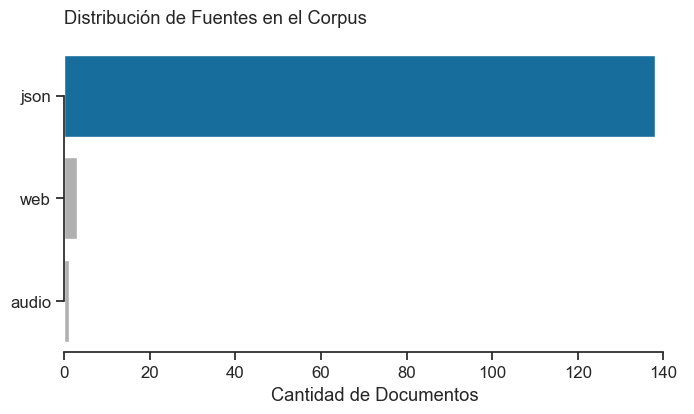

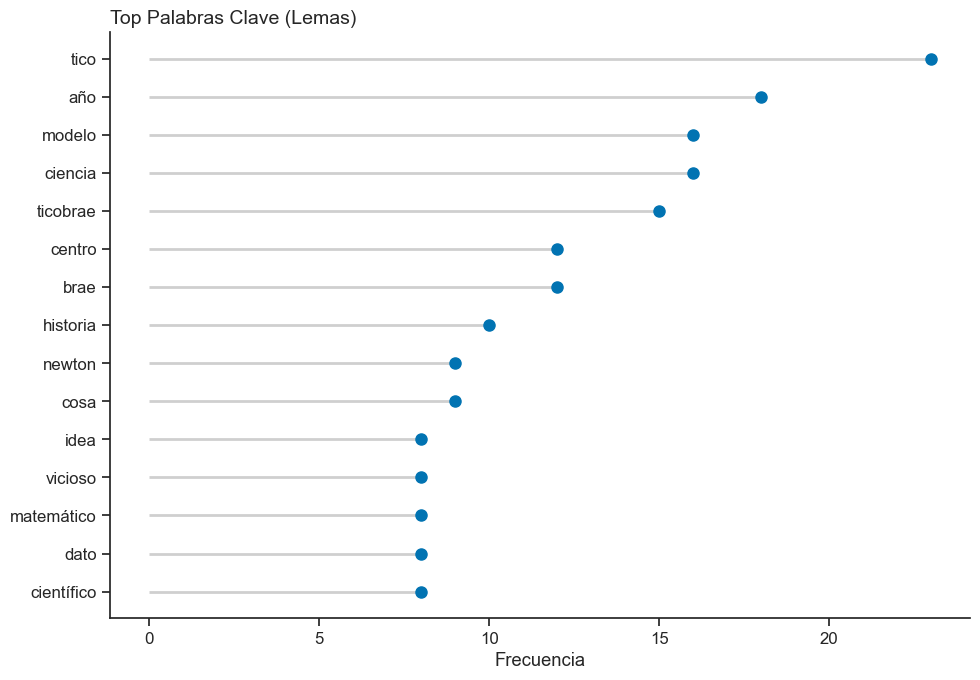

In [38]:
import gradio as gr
import pandas as pd

def filtrar_menciones_entidad(entidad):
    """
    Función de backend que busca la entidad en los objetos Doc de spaCy
    y devuelve una tabla con el origen y la oración exacta.
    """
    if not entidad or not hasattr(pipeline, 'df'):
        return pd.DataFrame(columns=["Origen", "Contexto de la mención"])
    
    resultados = []
    # Buscamos en el DataFrame que ya tiene la columna 'doc' procesada
    for _, fila in pipeline.df.iterrows():
        doc = fila['doc']
        for oracion in doc.sents:
            if entidad.lower() in oracion.text.lower():
                resultados.append([fila['origen'], oracion.text.strip()])
    
    return pd.DataFrame(resultados, columns=["Origen", "Contexto de la mención"])

# --- CONSTRUCCIÓN DEL DASHBOARD ---

with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("# 📊 Explorador de Agenda Mediática")
    gr.Markdown("Análisis automatizado de fuentes web, audio y prensa escrita.")
    
    with gr.Tab("Panorama y Métricas"):
        gr.Markdown("### 📈 Estado General del Corpus")
        
        with gr.Row():
            # Mostramos las métricas generales en formato tabla para lectura rápida
            if pipeline.analizador:
                stats = pipeline.analizador.estadisticas_corpus()
                df_stats = pd.DataFrame([stats])
                gr.Dataframe(df_stats, label="Métricas de Procesamiento Lingüístico")
        
        with gr.Row():
            # Visualizaciones estáticas (Seaborn/Matplotlib)
            gr.Plot(visualizar_origen(pipeline.df), label="Distribución de Fuentes")
            gr.Plot(visualizar_palabras_clave_lollipop(pipeline.analizador.extraer_palabras_clave(15)), label="Top 15 Lemas Clave")
        
        # Panel de Entidades (Plotly Interactivo)
        gr.Plot(visualizar_entidades_plotly(pipeline.analizador.extraer_entidades()), label="Frecuencia de Entidades (PER, ORG, LOC)")
        
    with gr.Tab("Explorador de Entidades"):
        gr.Markdown("### 🔍 Buscador de Contexto")
        gr.Markdown("Ingresá una entidad (ej. 'IA', 'Gobierno', un nombre propio) para extraer las oraciones donde se menciona.")
        
        with gr.Row():
            texto_busqueda = gr.Textbox(
                label="Entidad a rastrear", 
                placeholder="Escribí aquí..."
            )
            boton_ejecutar = gr.Button("Filtrar Oraciones", variant="primary")
        
        # Resultado de la búsqueda
        tabla_resultados = gr.Dataframe(
            label="Menciones encontradas",
            wrap=True # Para que las oraciones largas no se corten
        )
        
        # Conexión lógica: el botón dispara la función de filtrado
        boton_ejecutar.click(
            fn=filtrar_menciones_entidad, 
            inputs=texto_busqueda, 
            outputs=tabla_resultados
        )

# Lanzamiento del dashboard
dashboard_medios.launch()

In [ ]:
# PASO 1: Diseñá el bloque principal de gr.Blocks() interactuando con los métodos de la clase AnalizadorCorpus.
# Sugerencia: Utilizá pestañas (gr.Tab) para separar "Métricas Generales" de "Filtros e Interacción".

with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("# Explorador de Agenda Mediática")
    
    with gr.Tab("Panorama y Métricas"):
        # Incluí acá la visualización de frecuencias y orígenes, acompañando un gr.DataFrame con métricas generales.
        pass
        
    with gr.Tab("Explorador de Entidades"):
        # Desarrollá un textbox para ingresar una entidad y un botón que dispare
        # un filtrado, mostrando sólo las oraciones dentro de los textos donde se mencionó dicha entidad.
        pass

# Descomentá la siguiente línea cuando el bloque esté terminado
# dashboard_medios.launch()

C:\Users\vpena\AppData\Local\Temp\ipykernel_25572\2256453203.py:4: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:


---
## Cierre Formal y Checklist de Entrega

1. ¿Corriste el pipeline de principio a fin, comprobando que las funciones se anidan y comparten el DataFrame correctamente?
2. ¿Tu *AI Reflection Log* evidencia que cuestionaste a la IA y al modelo algorítmico, o todas tus celdas dicen "me devolvió un código y lo usé"?
3. ¿Revisaste el impacto visual de los gráficos garantizando que minimizan la "tinta algorítmica" (Data-Ink Ratio)?
4. ¿Justificaste tus decisiones de arquitectura técnica en el código de orquestación y exportación?

Si respondiste positivamente: felicitaciones, completaste el **TPI 1** demostrando un uso constructivo de la IA, asumiendo un rol profesional capaz de dirigir la automatización de forma estratégica e informada.